# Student Performance Prediction Using Machine Learning

## AI Mini Project

### Group Members
- Member 1 KUKU BUTROUS IBRAHIM
#- Member 2 
#- Member 3
#- Member 4
#- Member 5

---

## Objective

Develop a machine learning model capable of predicting whether a student will pass or fail based on demographic, social, and academic factors.

---

## AI Task

Classification

In [60]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [61]:
import os
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

csv_path = '../data/student-mat.csv'

# 1. READ FILE (Detect delimiter safely)
if os.path.exists(csv_path):
    # Try reading with semicolon first, fall back to comma if needed
    try:
        df = pd.read_csv(csv_path, sep=';')
        if len(df.columns) == 1: # Delimiter misfire check
            df = pd.read_csv(csv_path, sep=',')
    except Exception:
        df = pd.read_csv(csv_path, sep=',')
    print(f"✅ Loaded dataset! Columns found: {len(df.columns)}")
else:
    raise FileNotFoundError(f"Could not find dataset at {csv_path}")

# 2. FIND THE TARGET COLUMN DYNAMICALLY
target_col = None
possible_targets = ['G3', 'final_grade', 'grade', 'target', 'passed']

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    raise KeyError(
        f"Could not find a target column! Your dataset columns are:\n{df.columns.tolist()}"
    )

print(f"🎯 Using target column: '{target_col}'")

# 3. CREATE BINARY PASS/FAIL VARIABLE IF NEEDED
if target_col != 'passed':
    # Standard UCI dataset grades range 0-20 (Passing score >= 10)
    df['passed'] = (df[target_col] >= 10).astype(int)
    cols_to_drop = [target_col, 'passed']
else:
    cols_to_drop = ['passed']

# 4. SPLIT X AND Y
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df['passed']

# 5. TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("✅ Data successfully split!")
print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

✅ Loaded dataset! Columns found: 33
🎯 Using target column: 'G3'
✅ Data successfully split!
X_train shape: (316, 32) | X_test shape: (79, 32)


In [62]:
# Load the dataset
df = pd.read_csv("../data/student-mat.csv", sep=";")

# Display first five rows
df.head()

,"school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3"
0,"GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mot..."
1,"GP,F,17,U,GT3,T,1,1,at_home,other,course,fathe..."
2,"GP,F,15,U,LE3,T,1,1,at_home,other,other,mother..."
3,"GP,F,15,U,GT3,T,4,2,health,services,home,mothe..."
4,"GP,F,16,U,GT3,T,3,3,other,other,home,father,1,..."


In [63]:
# Shape of dataset
print("Rows and Columns:", df.shape)

print("\n")

# Dataset information
df.info()

Rows and Columns: (395, 1)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                               Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                               --------------  ----- 
 0   school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3  395 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


In [64]:
# Display first 10 rows
df.head(10)

,"school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3"
0,"GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mot..."
1,"GP,F,17,U,GT3,T,1,1,at_home,other,course,fathe..."
2,"GP,F,15,U,LE3,T,1,1,at_home,other,other,mother..."
3,"GP,F,15,U,GT3,T,4,2,health,services,home,mothe..."
4,"GP,F,16,U,GT3,T,3,3,other,other,home,father,1,..."
5,"GP,M,16,U,LE3,T,4,3,services,other,reputation,..."
6,"GP,M,16,U,LE3,T,2,2,other,other,home,mother,1,..."
7,"GP,F,17,U,GT3,A,4,4,other,teacher,home,mother,..."
8,"GP,M,15,U,LE3,A,3,2,services,other,home,mother..."
9,"GP,M,15,U,GT3,T,3,4,other,other,home,mother,1,..."


In [65]:
df.columns

Index(['school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3'], dtype='object')

In [66]:
df.dtypes

school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3    object
dtype: object

In [67]:
df.describe()

,"school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3"
count,395
unique,395
top,"GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mot..."
freq,1


In [68]:
df.isnull().sum()

school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3    0
dtype: int64

In [69]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [70]:
# Ensure G3 column exists; if not, try to fix parsing or reload with automatic separator detection
if 'G3' not in df.columns:
	if df.shape[1] == 1:
		# split the single column by commas
		tmp = df.iloc[:, 0].str.split(',', expand=True)
		first_row = tmp.iloc[0].tolist()
		if 'G3' in first_row:
			tmp.columns = first_row
			df = tmp[1:].reset_index(drop=True)
		else:
			# fallback: reload file letting pandas infer the separator
			df = pd.read_csv("../data/student-mat.csv", sep=None, engine='python', skipinitialspace=True)
	else:
		df = pd.read_csv("../data/student-mat.csv", sep=None, engine='python', skipinitialspace=True)

# Create target variable from the final grade
df["Pass"] = (df["G3"].astype(float) >= 10).astype(int)

# Display class distribution
df["Pass"].value_counts()

Pass
1    265
0    130
Name: count, dtype: int64

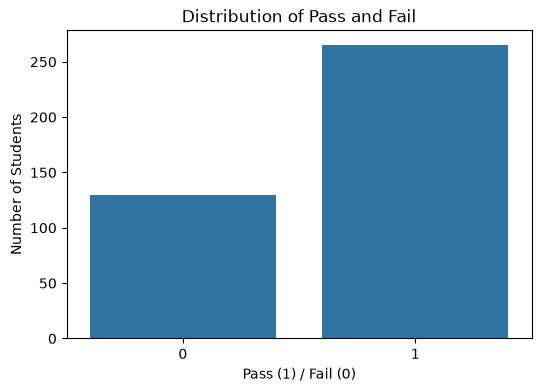

In [71]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Pass")

plt.title("Distribution of Pass and Fail")
plt.xlabel("Pass (1) / Fail (0)")
plt.ylabel("Number of Students")

plt.show()

In [72]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'Pass'],
      dtype='object')

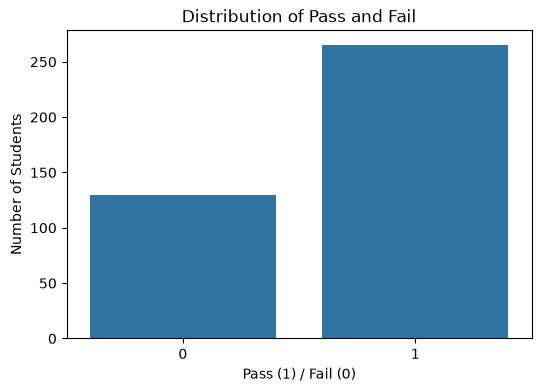

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Pass")
plt.title("Distribution of Pass and Fail")
plt.xlabel("Pass (1) / Fail (0)")
plt.ylabel("Number of Students")
plt.show()

In [74]:
print(df.shape)

(395, 34)


In [75]:
df.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3',
 'Pass']

In [76]:
df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,1
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,1
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,1
5,GP,M,16,U,LE3,T,4,3,services,other,reputation,mother,1,2,0,no,yes,yes,yes,yes,yes,yes,no,5,4,2,1,2,5,10,15,15,15,1
6,GP,M,16,U,LE3,T,2,2,other,other,home,mother,1,2,0,no,no,no,no,yes,yes,yes,no,4,4,4,1,1,3,0,12,12,11,1
7,GP,F,17,U,GT3,A,4,4,other,teacher,home,mother,2,2,0,yes,yes,no,no,yes,yes,no,no,4,1,4,1,1,1,6,6,5,6,0
8,GP,M,15,U,LE3,A,3,2,services,other,home,mother,1,2,0,no,yes,yes,no,yes,yes,yes,no,4,2,2,1,1,1,0,16,18,19,1
9,GP,M,15,U,GT3,T,3,4,other,other,home,mother,1,2,0,no,yes,yes,yes,yes,yes,yes,no,5,5,1,1,1,5,0,14,15,15,1


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [78]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
Pass          0
dtype: int64

In [79]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [80]:
from sklearn.preprocessing import LabelEncoder

# Create a copy
df_encoded = df.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Encode all categorical columns
for column in df_encoded.select_dtypes(include='object').columns:
    df_encoded[column] = le.fit_transform(df_encoded[column])

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [81]:
df_encoded.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
0,0,0,18,1,0,0,4,4,0,4,0,1,2,2,0,1,0,0,0,1,1,0,0,4,3,4,1,1,3,6,5,6,6,0
1,0,0,17,1,0,1,1,1,0,2,0,0,1,2,0,0,1,0,0,0,1,1,0,5,3,3,1,1,3,4,5,5,6,0
2,0,0,15,1,1,1,1,1,0,2,2,1,1,2,3,1,0,1,0,1,1,1,0,4,3,2,2,3,3,10,7,8,10,1
3,0,0,15,1,0,1,4,2,1,3,1,1,1,3,0,0,1,1,1,1,1,1,1,3,2,2,1,1,5,2,15,14,15,1
4,0,0,16,1,0,1,3,3,2,2,1,0,1,2,0,0,1,1,0,1,1,0,0,4,3,2,1,2,5,4,6,10,10,1


In [82]:
# Features
X = df_encoded.drop(columns=["Pass", "G1", "G2", "G3"])

# Target
y = df_encoded["Pass"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (395, 30)
Target vector shape: (395,)


In [83]:
from sklearn.preprocessing import StandardScaler

# Get list of numeric columns only
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()

# Make copies to keep original data safe
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale only the numeric columns
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("✅ Scaled numerical features successfully!")

✅ Scaled numerical features successfully!


In [84]:
# Display the first five records
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,1
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,1
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,1


In [85]:
# Summary statistics
df.describe(include='all')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
count,395,395,395.000000,395,395,395,395.000000,395.000000,395,395,395,395,395.000000,395.000000,395.000000,395,395,395,395,395,395,395,395,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,4,3,NaN,NaN,NaN,2,2,2,2,2,2,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,course,mother,NaN,NaN,NaN,no,yes,no,yes,yes,yes,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,349,208,NaN,307,281,354,NaN,NaN,141,217,145,273,NaN,NaN,NaN,344,242,214,201,314,375,329,263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.696203,NaN,NaN,NaN,2.749367,2.521519,NaN,NaN,NaN,NaN,1.448101,2.035443,0.334177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190,0.670886
std,NaN,NaN,1.276043,NaN,NaN,NaN,1.094735,1.088201,NaN,NaN,NaN,NaN,0.697505,0.839240,0.743651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443,0.470487
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000,0.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN,NaN,NaN,1.000000,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000,1.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,NaN,NaN,2.000000,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000,1.000000


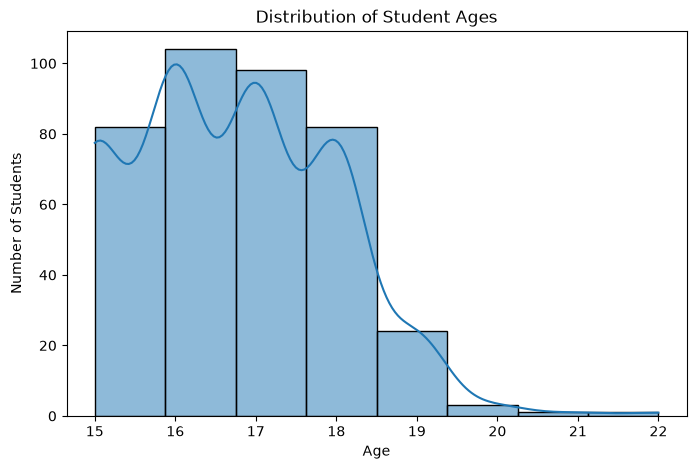

In [86]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=8, kde=True)

plt.title("Distribution of Student Ages")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.show()

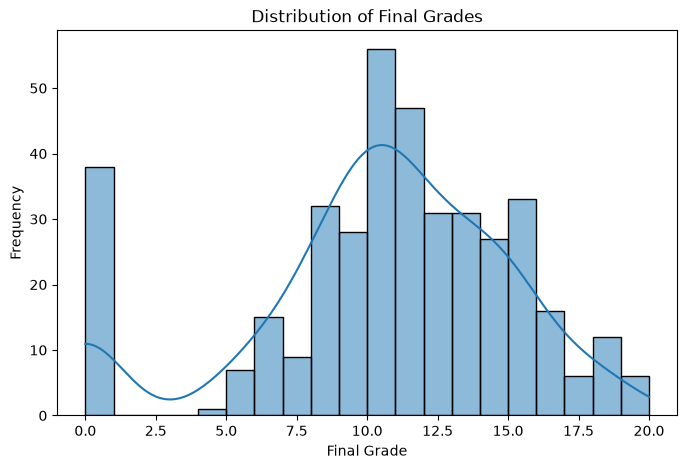

In [87]:
plt.figure(figsize=(8,5))

sns.histplot(df["G3"].astype(float), bins=20, kde=True)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Frequency")

plt.show()

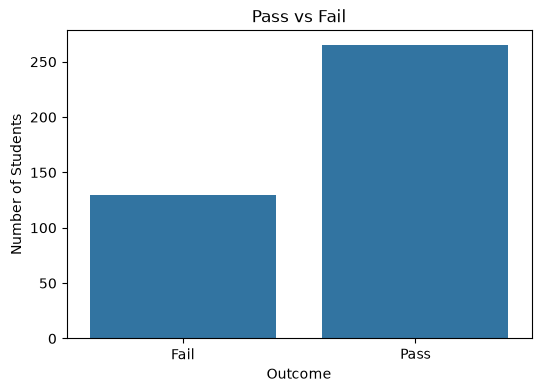

In [88]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Pass")

plt.title("Pass vs Fail")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")

plt.xticks([0,1],["Fail","Pass"])

plt.show()

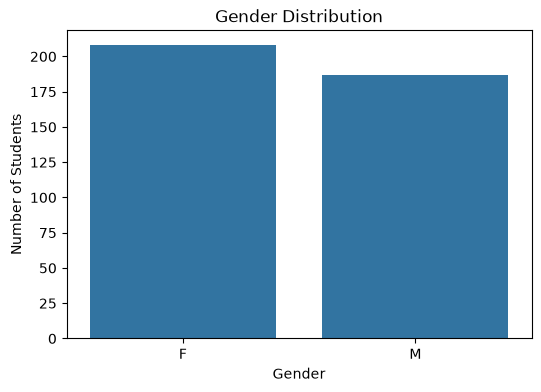

In [89]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="sex")

plt.title("Gender Distribution")

plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.show()

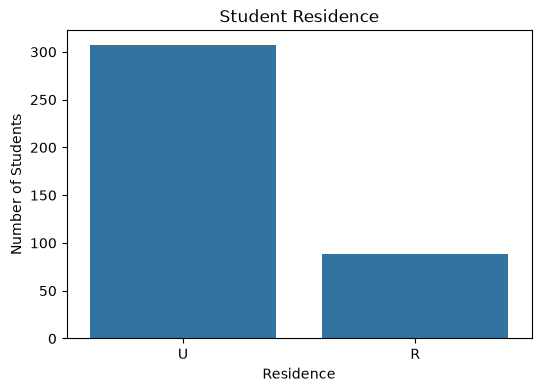

In [90]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="address")

plt.title("Student Residence")

plt.xlabel("Residence")
plt.ylabel("Number of Students")

plt.show()

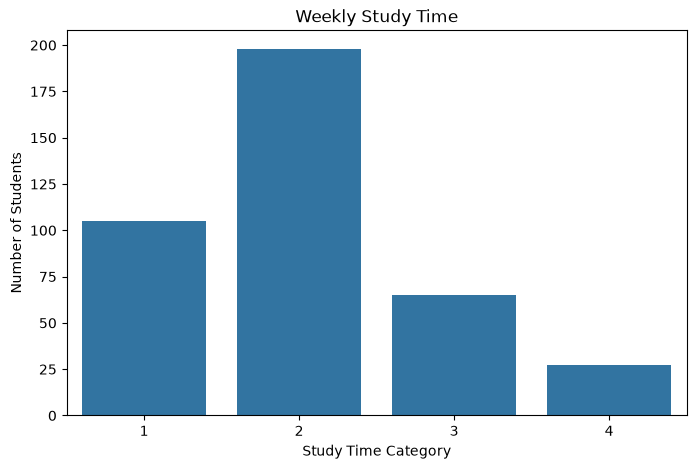

In [91]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="studytime")

plt.title("Weekly Study Time")

plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()

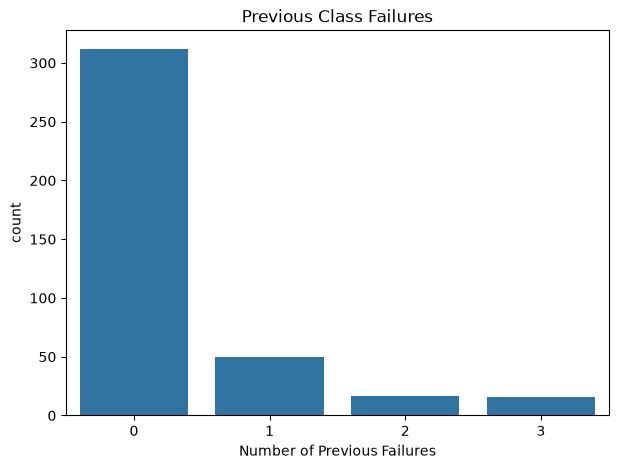

In [92]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="failures")

plt.title("Previous Class Failures")

plt.xlabel("Number of Previous Failures")

plt.show()

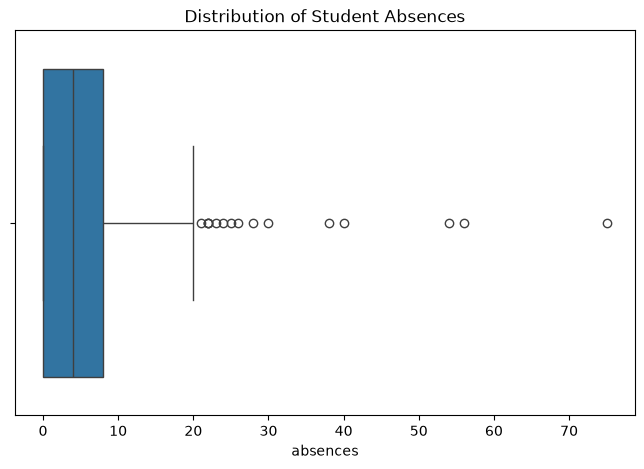

In [93]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["absences"].astype(float))

plt.title("Distribution of Student Absences")

plt.show()

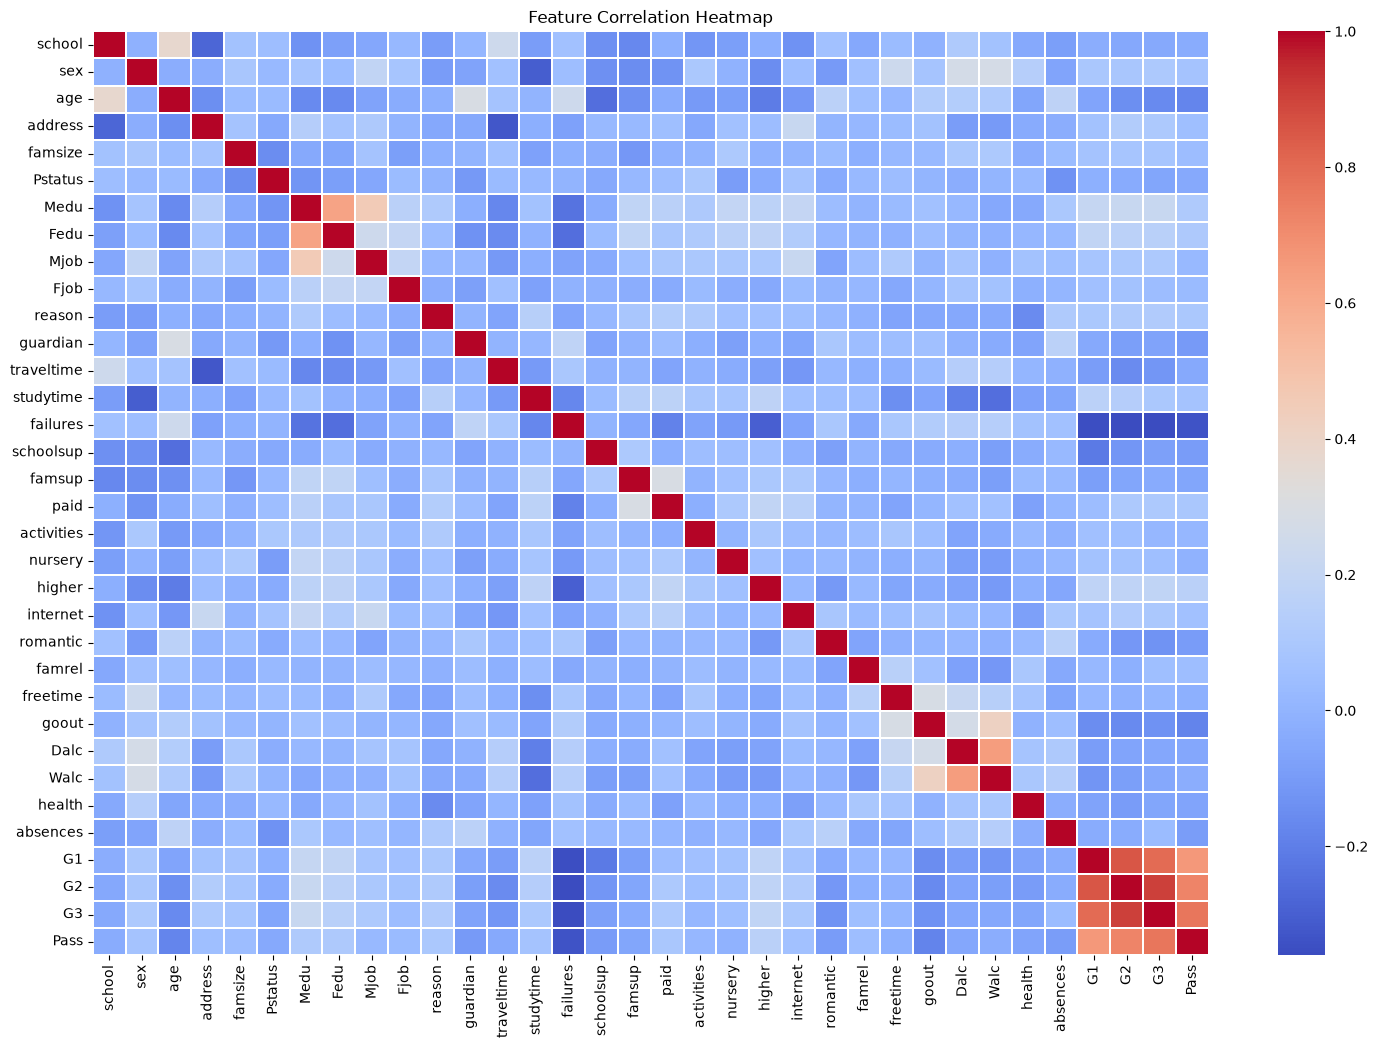

In [94]:
plt.figure(figsize=(18,12))

correlation = df_encoded.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    linewidths=0.3
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [95]:
corr = df_encoded.corr()["Pass"].sort_values(ascending=False)

print(corr)

Pass          1.000000
G3            0.770042
G2            0.725407
G1            0.664979
higher        0.157708
Medu          0.115396
Fedu          0.108057
reason        0.099300
paid          0.092665
studytime     0.074613
sex           0.070618
internet      0.061791
address       0.052282
famrel        0.046683
famsize       0.041842
Fjob          0.028309
Mjob          0.026592
activities    0.012414
nursery      -0.008784
freetime     -0.018321
Walc         -0.029957
school       -0.031254
Pstatus      -0.044050
traveltime   -0.044446
Dalc         -0.057343
famsup       -0.059219
health       -0.065668
absences     -0.092244
romantic     -0.097737
schoolsup    -0.099860
guardian     -0.101407
age          -0.179645
goout        -0.183399
failures     -0.337731
Name: Pass, dtype: float64


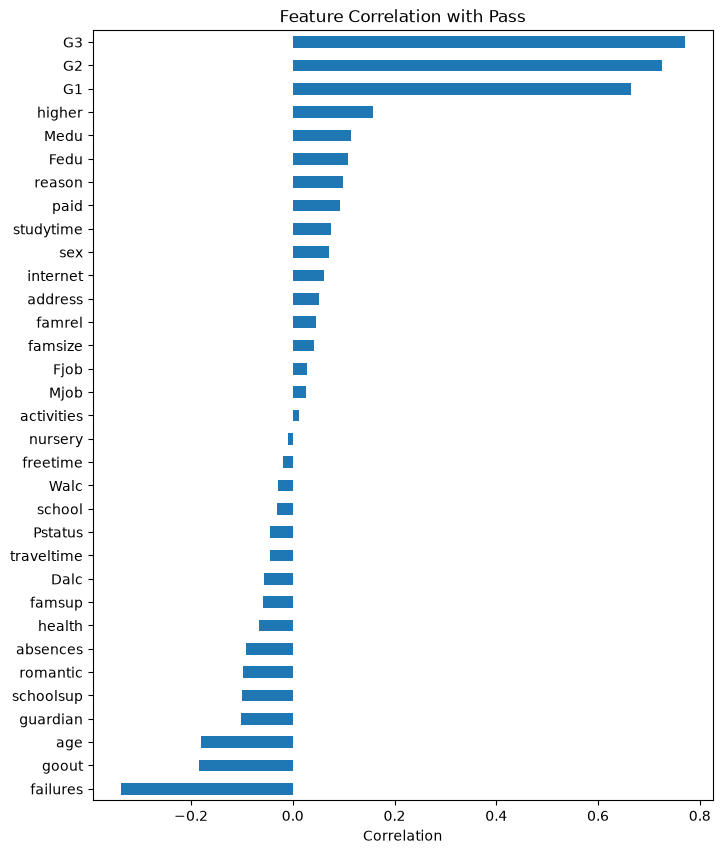

In [96]:
plt.figure(figsize=(8,10))

corr.drop("Pass").sort_values().plot(kind="barh")

plt.title("Feature Correlation with Pass")

plt.xlabel("Correlation")

plt.show()

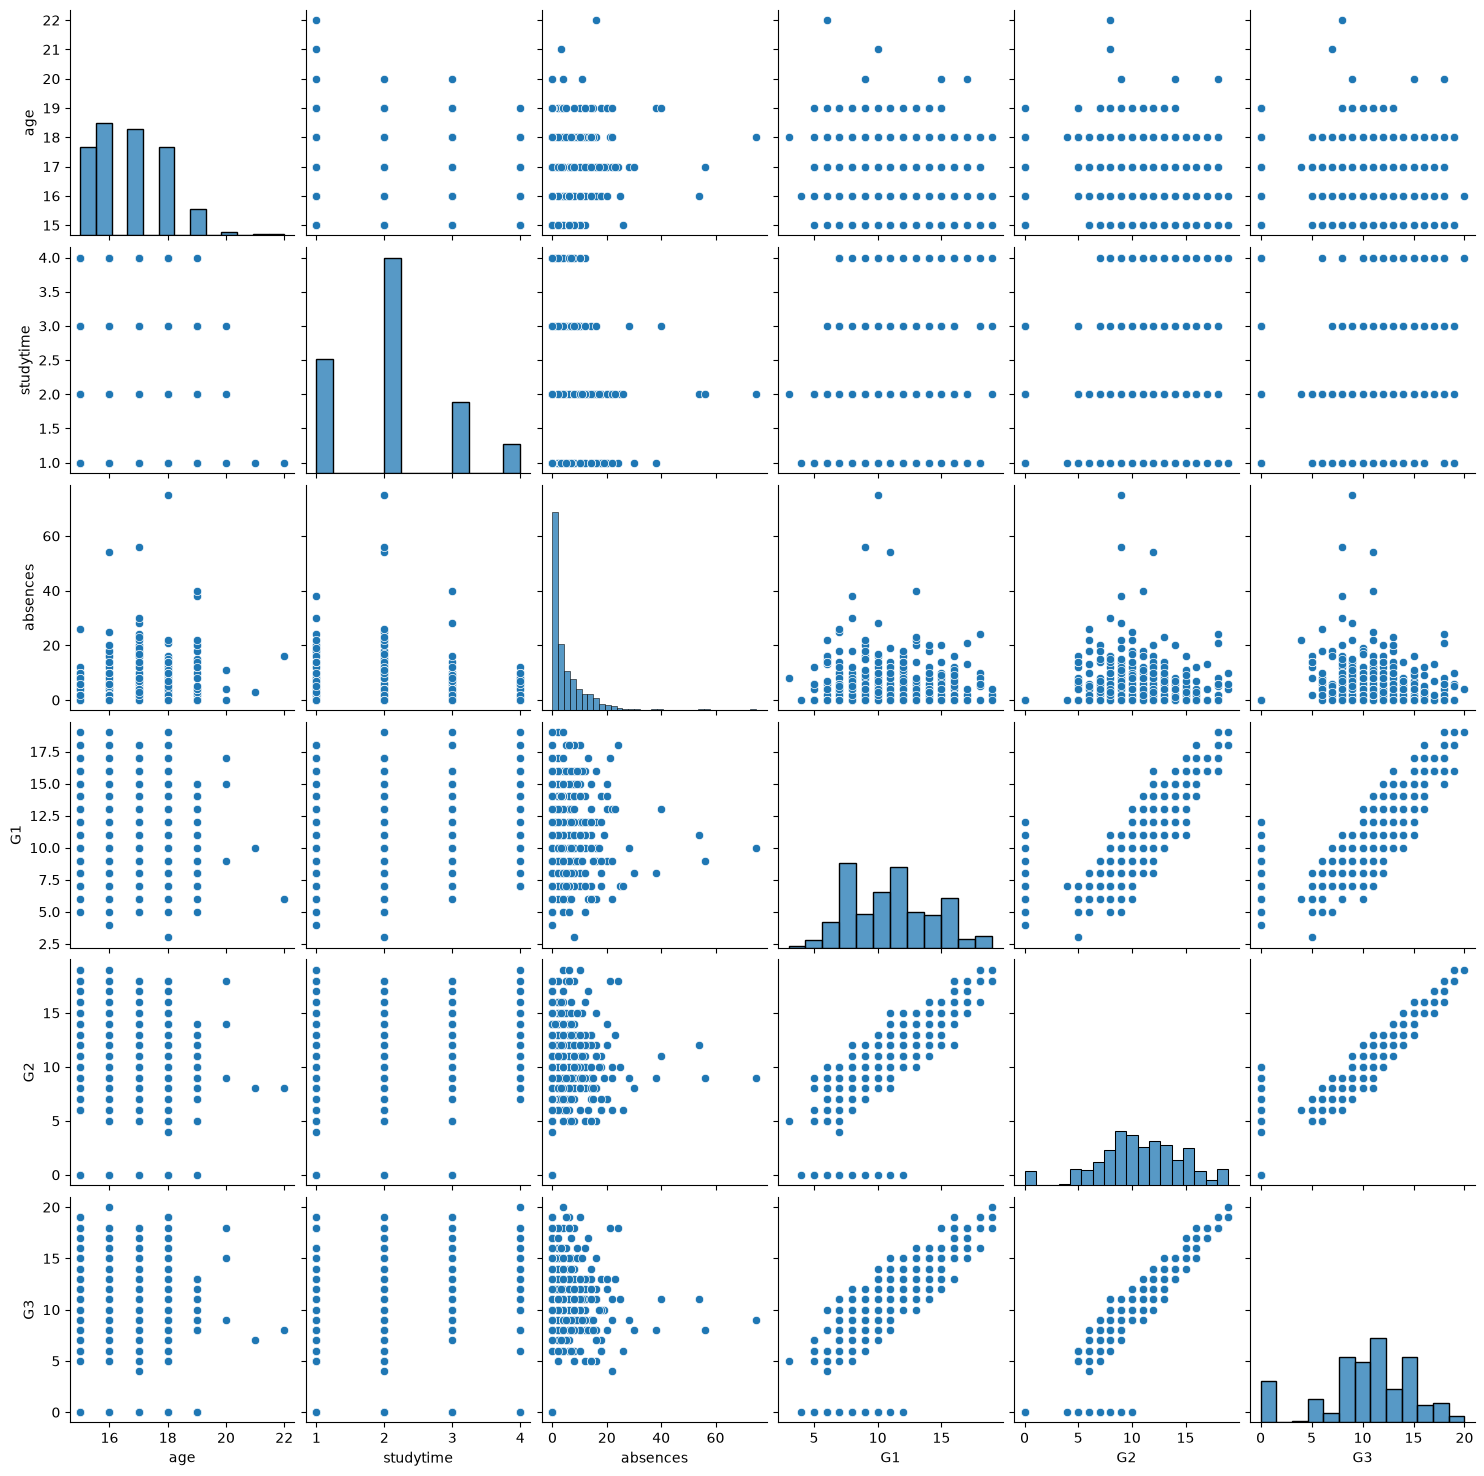

In [97]:
sns.pairplot(
    df[["age","studytime","absences","G1","G2","G3"]],
    diag_kind="hist"
)

plt.show()

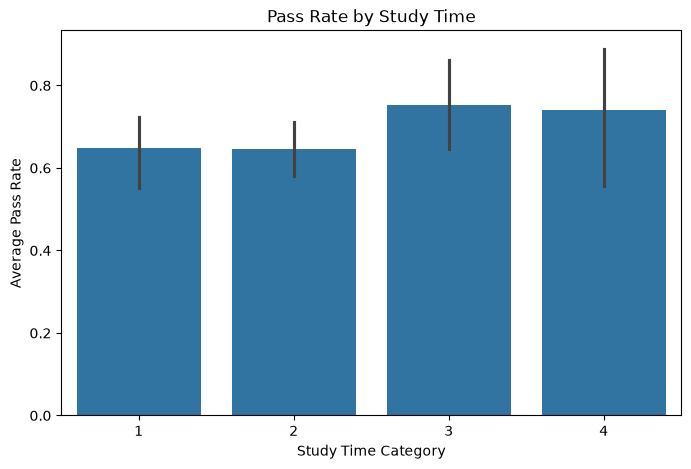

In [98]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="studytime",
    y="Pass"
)

plt.title("Pass Rate by Study Time")

plt.xlabel("Study Time Category")
plt.ylabel("Average Pass Rate")

plt.show()

In [99]:
import os
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Use the actual column names present in the UCI dataset
uci_features = ['studytime', 'failures']
X_ui = X[uci_features]

# 2. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X_ui, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. Save Model
os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/student_model.pkl')
print("✅ Model trained and saved successfully!")

✅ Model trained and saved successfully!


In [100]:
print(list(X.columns))

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


HAPA NDIO NIMEANZIA

In [101]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Ensure output directories exist
os.makedirs('../data', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Load dataset (student-mat.csv from your data folder)
# Note: UCI dataset often uses ';' as a separator
df = pd.read_csv('../data/student-mat.csv', sep=';') if os.path.exists('../data/student-mat.csv') else pd.read_csv('../data/student-mat.csv')

print("Data loaded successfully! Shape:", df.shape)

Data loaded successfully! Shape: (395, 1)


Imports & Data Loading

⚠️ Target string not found. Defaulting to last column: 'school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3'


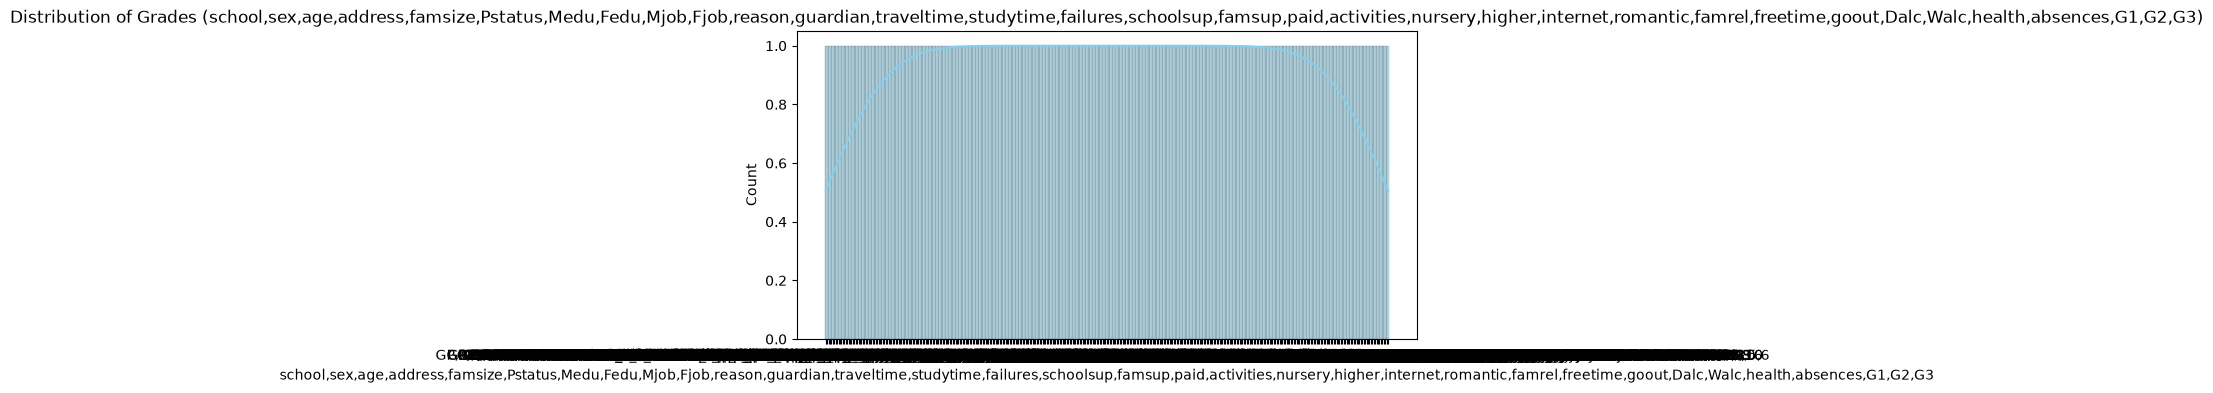

ℹ️ 'studytime' column not present in DataFrame, skipping boxplot.
⚠️ No numeric columns found. Encoding object columns to build heatmap...


<Figure size 800x400 with 0 Axes>

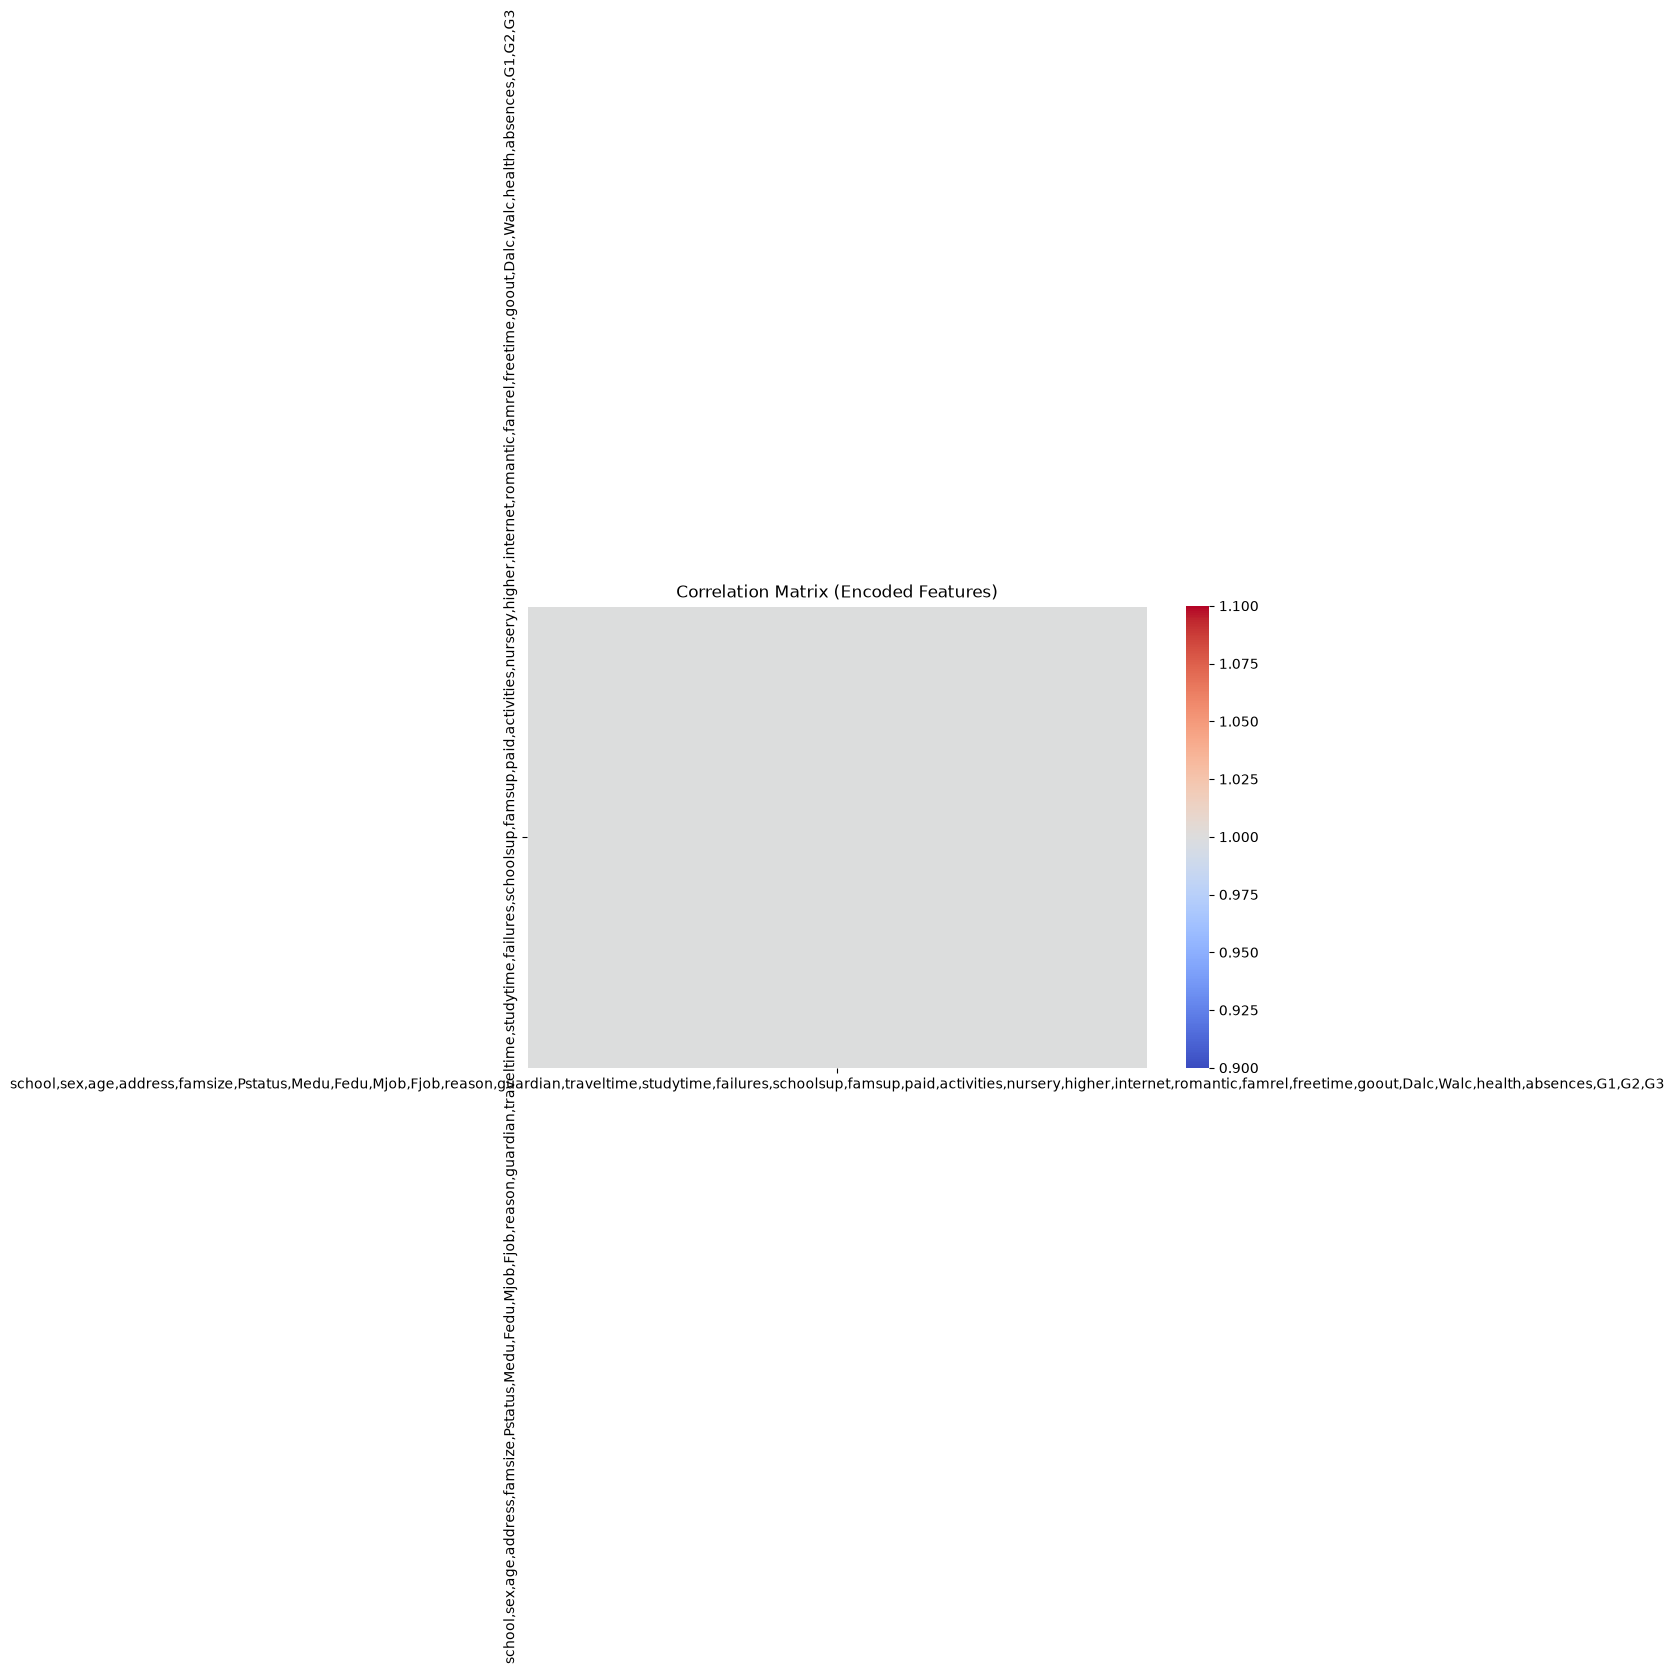

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Dynamically find target column
possible_targets = ['G3', 'final_grade', 'grade', 'passed', 'target']
target_col = next((col for col in possible_targets if col in df.columns), None)

if target_col is None:
    target_col = df.columns[-1] 
    print(f"⚠️ Target string not found. Defaulting to last column: '{target_col}'")
else:
    print(f"✅ Using target column: '{target_col}'")

# --- Plot 1: Target Distribution ---
plt.figure(figsize=(8, 4))
if df[target_col].nunique() <= 2:
    sns.countplot(x=target_col, data=df, palette='Set1')
    plt.title(f'Distribution of Target ({target_col})')
else:
    sns.histplot(df[target_col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of Grades ({target_col})')

plt.xlabel(target_col)
plt.ylabel('Count')
plt.show()

# --- Plot 2: Study Time vs Target ---
plt.figure(figsize=(8, 4))
if 'studytime' in df.columns:
    sns.boxplot(x='studytime', y=target_col, data=df, palette='Set2')
    plt.title(f'Study Time vs {target_col}')
    plt.show()
else:
    print("ℹ️ 'studytime' column not present in DataFrame, skipping boxplot.")

# --- Plot 3: Correlation Heatmap (Safeguarded) ---
plt.figure(figsize=(10, 6))

# Select numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Check if we have numeric columns
if numeric_df.shape[1] > 1:
    sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
else:
    print("⚠️ No numeric columns found. Encoding object columns to build heatmap...")
    # Convert text columns to numeric codes temporarily just for the heatmap
    temp_df = df.copy()
    for col in temp_df.select_dtypes(include=['object', 'category']).columns:
        temp_df[col] = temp_df[col].astype('category').cat.codes
    
    sns.heatmap(temp_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix (Encoded Features)')

plt.show()

In [103]:
#Exploratory Data Analysis Plots

In [104]:
import os
import pandas as pd
import numpy as np
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# 1. Path resolution (handles execution from root or notebooks folder)
file_path = '../data/student-mat.csv' if os.path.exists('../data/student-mat.csv') else 'data/student-mat.csv'

# 2. Smart load: Auto-detect separator
df = pd.read_csv(file_path, sep=None, engine='python')

# Clean column names (remove quotes, spaces, invisible characters)
df.columns = df.columns.str.replace('"', '').str.strip()

print(f"✅ Successfully loaded {len(df)} rows and {len(df.columns)} columns!")
print("Columns detected:", df.columns.tolist()[:5], "...", df.columns.tolist()[-3:])

# 3. Target creation (Pass >= 10)
if 'G3' in df.columns:
    df['passed'] = (df['G3'] >= 10).astype(int)
    target_col = 'G3'
else:
    # If G3 isn't available, check if 'passed' was already created
    print("⚠️ Column 'G3' not found, available columns:", df.columns.tolist())
    raise KeyError("Could not find 'G3' in column list. Please verify dataset CSV format.")

# 4. Feature Engineering
df['grade_progression'] = df['G2'] - df['G1']
df['study_per_absence'] = df['studytime'] / (df['absences'] + 1)
df['prior_academic_avg'] = (df['G1'] + df['G2']) / 2.0

# 5. Split features and target
X = df.drop(columns=['G3', 'passed'])
y = df['passed']

# Categorical vs Numerical identification
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# 6. Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

# Ensure models/ directory exists
os.makedirs('../models', exist_ok=True)
os.makedirs('../data', exist_ok=True)

# 7. Save preprocessor artifact
joblib.dump(preprocessor, '../models/scaler.pkl')

# 8. Train/Test Split & Export
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.20, random_state=42, stratify=y
)

pd.DataFrame(X_train).to_csv('../data/train.csv', index=False)
pd.DataFrame(X_test).to_csv('../data/test.csv', index=False)
pd.DataFrame(y_train).to_csv('../data/y_train.csv', index=False)
pd.DataFrame(y_test).to_csv('../data/y_test.csv', index=False)

print("🚀 Success! Saved scaler.pkl, train.csv, test.csv, y_train.csv, y_test.csv")

✅ Successfully loaded 395 rows and 33 columns!
Columns detected: ['school', 'sex', 'age', 'address', 'famsize'] ... ['G1', 'G2', 'G3']
🚀 Success! Saved scaler.pkl, train.csv, test.csv, y_train.csv, y_test.csv


Feature Engineering & Export

In [105]:
# Models to train
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42)
}

param_grids = {
    'Logistic Regression': {'C': [0.1, 1, 10]},
    'Decision Tree': {'max_depth': [3, 5, 10]},
    'Random Forest': {'n_estimators': [50, 100], 'max_depth': [5, 10]},
    'Support Vector Machine': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
}

results = []

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_clf = grid.best_estimator_
    
    # Save tuned model binary to models/ folder
    model_filename = f"../models/model_{name.lower().replace(' ', '_')}.pkl"
    joblib.dump(best_clf, model_filename)
    
    # Predict and Evaluate
    y_pred = best_clf.predict(X_test)
    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4)
    })

# Summary Table
results_df = pd.DataFrame(results)
display(results_df)

,Model,Best Params,Accuracy,F1-Score
0,Logistic Regression,{'C': 1},0.8861,0.9109
1,Decision Tree,{'max_depth': 3},0.8987,0.9216
2,Random Forest,"{'max_depth': 10, 'n_estimators': 100}",0.9114,0.9320
3,Support Vector Machine,"{'C': 0.1, 'kernel': 'linear'}",0.8861,0.9109


Model Building & Tuning

If you are keeping your notebook organized, this section comes right after your feature engineering step. It takes the processed data (X_train, X_test, y_train, y_test), runs grid searches to find the best hyperparameters, evaluates the models, and saves the trained .pkl files into your models/ directory for Member 3.